# RealMLP Approach on Predicting Heart Disease

- PB: 0.95361
- Purpose:
    - Remove HPO and measure LB
    -

### Package import

In [1]:
!pip install pytabkit -q

from pathlib import Path
import json
import zipfile
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import warnings
from sklearn.metrics import roc_auc_score
from pytabkit import RealMLP_TD_Classifier
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# ---- Config ----
COMP_SLUG = "playground-series-s6e2"
KAGGLE_COMP_DIR = Path("/kaggle/input/competitions/playground-series-s6e2")
KAGGLE_EXT_PATH = Path("/kaggle/input/datasets/neurocipher/heartdisease/Heart_Disease_Prediction.csv")

LOCAL_DATA_DIR = Path("data/raw")
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

NEED_FILES = ["train.csv", "test.csv", "sample_submission.csv"]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 7.7 MB/s eta 0:00:00


In [2]:
def run(cmd: list[str]) -> None:
    p = subprocess.run(cmd, capture_output=True, text=True)
    p.check_returncode()


def ensure_kaggle_cli() -> None:
    try:
        pass
    except Exception:
        subprocess.check_call(["pip", "-q", "install", "kaggle"])


def ensure_kaggle_json_interactive_colab(dst: Path = Path("/content/kaggle.json")) -> Path:
    """
    In Colab: open upload dialog if /content/kaggle.json is missing.
    In non-Colab: just require the file to exist.
    """
    if dst.exists():
        print("Found:", dst)
        return dst

    try:
        from google.colab import files  # type: ignore
    except Exception:
        raise FileNotFoundError(
            f"{dst} not found. Please place kaggle.json at {dst} (Colab) "
            "or provide credentials another way."
        )

    print("Upload your kaggle.json (Kaggle -> Account -> API -> Create New Token)")
    uploaded = files.upload()
    cand = None
    if "kaggle.json" in uploaded:
        cand = "kaggle.json"
    else:
        for name in uploaded.keys():
            if name.endswith(".json"):
                cand = name
                break
    if cand is None:
        raise FileNotFoundError("Upload failed: no .json file received.")

    Path(cand).rename(dst)
    print("Saved to:", dst)
    return dst


def install_kaggle_json(src: Path) -> None:
    """
    Copy /content/kaggle.json -> ~/.kaggle/kaggle.json (chmod 600)
    """
    if not src.exists():
        raise FileNotFoundError(f"{src} not found.")

    dst_dir = Path.home() / ".kaggle"
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = dst_dir / "kaggle.json"

    dst.write_bytes(src.read_bytes())
    try:
        dst.chmod(0o600)
    except Exception:
        pass

    cfg = json.loads(dst.read_text())
    if "username" not in cfg or "key" not in cfg:
        raise ValueError("kaggle.json is missing 'username' or 'key'.")
    print(f"Installed kaggle.json for user: {cfg['username']}")


def local_data_ready(data_dir: Path) -> bool:
    return all((data_dir / f).exists() for f in NEED_FILES)


def download_competition_to(data_dir: Path) -> None:
    """
    Download competition zip(s) and extract into data_dir.
    Assumes kaggle CLI + credentials are ready.
    """
    run(["kaggle", "config", "view"])
    run(["kaggle", "competitions", "download", "-c", COMP_SLUG, "-p", str(data_dir), "--force"])

    zips = list(data_dir.glob("*.zip"))
    if not zips:
        raise FileNotFoundError(f"No zip found in {data_dir} after download.")

    for zp in zips:
        with zipfile.ZipFile(zp, "r") as zf:
            zf.extractall(data_dir)
        print("Unzipped:", zp.name)

    if not local_data_ready(data_dir):
        missing = [f for f in NEED_FILES if not (data_dir / f).exists()]
        raise FileNotFoundError(f"Download/unzip finished but missing: {missing}")


In [3]:
if KAGGLE_COMP_DIR.exists():
    DATA_SRC = "kaggle"
    data_dir = KAGGLE_COMP_DIR
    print("Using Kaggle mounted competition data:", data_dir)
else:
    DATA_SRC = "local"
    data_dir = LOCAL_DATA_DIR
    if local_data_ready(data_dir):
        print("Using local data (already present):", data_dir)
    else:
        print("Local data missing -> download using kaggle.json")
        ensure_kaggle_cli()
        kaggle_json_src = ensure_kaggle_json_interactive_colab(Path("/content/kaggle.json"))
        install_kaggle_json(kaggle_json_src)
        download_competition_to(data_dir)
        print("Download complete -> using local data:", data_dir)


# ---- Load ----
train = pd.read_csv(data_dir / "train.csv")
test  = pd.read_csv(data_dir / "test.csv")
sub   = pd.read_csv(data_dir / "sample_submission.csv")

# external dataset: only available if mounted on Kaggle; optional
original = pd.read_csv(KAGGLE_EXT_PATH) if KAGGLE_EXT_PATH.exists() else None

print("train:", train.shape, "test:", test.shape, "sub:", sub.shape, "original:", None if original is None else original.shape)
print("DATA_SRC:", DATA_SRC)


Using Kaggle mounted competition data: /kaggle/input/competitions/playground-series-s6e2
train: (630000, 15) test: (270000, 14) sub: (270000, 2) original: (270, 14)
DATA_SRC: kaggle


In [4]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.set_float32_matmul_precision("high")
N_FOLDS = 5
USE_ALL_CAT = True

print(f"Using device: {DEVICE}")


Using device: cuda


### Data download

In [5]:
display(train.head())
display(test.head())
display(sub.head())

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


,id,Heart Disease
0,630000,0
1,630001,0
2,630002,0
3,630003,0
4,630004,0


In [6]:
# Shapes
print("train:", train.shape)
print("test:", test.shape)

# Column diffs
train_cols = set(train.columns)
test_cols = set(test.columns)
print("Only in train:", sorted(train_cols - test_cols))
print("Only in test:", sorted(test_cols - train_cols))

# dtypes
train.dtypes.to_frame("dtype").head(30)


train: (630000, 15)
test: (270000, 14)
Only in train: ['Heart Disease']
Only in test: []


,dtype
id,int64
Age,int64
Sex,int64
Chest pain type,int64
BP,int64
Cholesterol,int64
FBS over 120,int64
EKG results,int64
Max HR,int64
Exercise angina,int64


### Data Preprocessing

In [7]:
def encode_target_strict(y: pd.Series) -> pd.Series:
    """Map common string labels to {0,1}. Raises if unknown."""
    mapping_candidates = [
        {"No": 0, "Yes": 1},
        {"N": 0, "Y": 1},
        {"Negative": 0, "Positive": 1},
        {"Absent": 0, "Present": 1},
        {"Absence": 0, "Presence": 1},
        {0: 0, 1: 1},
        {"0": 0, "1": 1},
    ]
    uniq = set(pd.Series(y).dropna().unique().tolist())
    for mp in mapping_candidates:
        if uniq.issubset(set(mp.keys())):
            return pd.Series(y).map(mp).astype("int8")
    raise ValueError(f"Unknown target labels: {sorted(list(uniq))}")


# ---- target ----
train["Heart Disease"] = encode_target_strict(train["Heart Disease"])
if original is not None and "Heart Disease" in original.columns:
    original["Heart Disease"] = encode_target_strict(original["Heart Disease"])

TARGET_COL = "Heart Disease"
ID_COL = "id"

BASE_FEATURES = [c for c in train.columns if c not in [TARGET_COL, ID_COL]]

# Canonical S6E2 semantic categoricals (keep as category for embeddings/encoding)
CANONICAL_CAT = {
    "Sex",
    "Chest pain type",
    "FBS over 120",
    "EKG results",
    "Exercise angina",
    "Slope of ST",
    "Number of vessels fluro",
    "Thallium",
}

def split_cols(df: pd.DataFrame):
    base = [c for c in df.columns if c not in [TARGET_COL, ID_COL]]
    cat = [c for c in base if c in CANONICAL_CAT]
    num = [c for c in base if c not in cat]
    return cat, num


def add_external_target_stats(df: pd.DataFrame, original_df: pd.DataFrame | None) -> pd.DataFrame:
    """Merge group-wise target stats from the external/original dataset.
    Safe in Playground comps because original_df labels are not the competition labels.
    """
    if original_df is None:
        return df.copy()

    out = df.copy()
    initial_rows = len(out)

    for col in BASE_FEATURES:
        if col not in original_df.columns:
            continue

        stats = (
            original_df.groupby(col)[TARGET_COL]
            .agg(["mean", "median", "std", "skew", "count"])
            .reset_index()
        )
        stats.columns = [col] + [f"orig_{col}_{s}" for s in ["mean", "median", "std", "skew", "count"]]

        out = out.merge(stats, on=col, how="left")
        if len(out) != initial_rows:
            raise ValueError(f"Merge expanded rows for column {col}! {initial_rows} -> {len(out)}")

        # fill NAs for unseen values
        global_mean = float(original_df[TARGET_COL].mean())
        global_median = float(original_df[TARGET_COL].median())
        fill = {
            f"orig_{col}_mean": global_mean,
            f"orig_{col}_median": global_median,
            f"orig_{col}_std": 0.0,
            f"orig_{col}_skew": 0.0,
            f"orig_{col}_count": 0.0,
        }
        out = out.fillna(value=fill)

    return out


def add_frequency_encoding(train_df: pd.DataFrame, test_df: pd.DataFrame, cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Add {col}_freq columns using combined train+test frequencies (unsupervised, safe)."""
    tr = train_df.copy()
    te = test_df.copy()

    combined = pd.concat([tr[cols], te[cols]], axis=0, ignore_index=True)
    for col in cols:
        freq = combined[col].value_counts(dropna=False)
        tr[f"{col}_freq"] = tr[col].map(freq).astype("float32")
        te[f"{col}_freq"] = te[col].map(freq).astype("float32")
    return tr, te


def add_binned_numerics(train_df: pd.DataFrame, test_df: pd.DataFrame, num_cols: list[str], n_bins: int = 10):
    tr = train_df.copy()
    te = test_df.copy()

    for col in num_cols:
        allv = pd.concat([tr[col], te[col]], axis=0, ignore_index=True)

        # If low cardinality, just reuse as "bin" (stable int codes)
        if allv.nunique(dropna=False) <= n_bins:
            tr[f"{col}_bin"] = pd.Series(tr[col]).astype("int32", errors="ignore")
            te[f"{col}_bin"] = pd.Series(te[col]).astype("int32", errors="ignore")
            continue

        try:
            bins = pd.qcut(allv.rank(method="first"), q=n_bins, labels=False, duplicates="drop")
        except Exception:
            bins = pd.cut(allv, bins=n_bins, labels=False, duplicates="drop")

        tr[f"{col}_bin"] = bins.iloc[:len(tr)].astype("int16")
        te[f"{col}_bin"] = bins.iloc[len(tr):].astype("int16")

    return tr, te


def build_features(
    train_fe: pd.DataFrame,
    test_fe: pd.DataFrame,
    cat_cols: list[str],
    num_cols: list[str],
    use_bins: bool,
):
    tr = train_fe.copy()
    te = test_fe.copy()

    if use_bins:
        # Add binned versions of continuous numerics (helps linear/MLP; low risk for GBDT too)
        # Important: keep 'orig_*' stats as numeric; they are already in num_cols here.
        # bin only "base continuous" numerics (exclude orig_* stats)
        num_cols_for_bins = [c for c in num_cols if not c.startswith("orig_")]
        tr, te = add_binned_numerics(tr, te, num_cols_for_bins, n_bins=10)

    print(f"Train Shape after FE: {tr.shape}")
    print(f"Test Shape after FE:  {te.shape}")

    # ---- Build X/y with clean dtypes ----
    drop_tr = [c for c in [TARGET_COL, ID_COL] if c in tr.columns]
    drop_te = [c for c in [ID_COL] if c in te.columns]

    X = tr.drop(columns=drop_tr).copy()
    X_test = te.drop(columns=drop_te).copy()
    y = tr[TARGET_COL].copy()

    bin_cols = [c for c in X.columns if c.endswith("_bin")]

    cat_cols_final = [c for c in X.columns if c in cat_cols] + (bin_cols if use_bins else [])
    num_cols_final = [c for c in X.columns if c not in cat_cols_final]

    for c in cat_cols_final:
        combined = pd.concat([X[c], X_test[c]], axis=0, ignore_index=True)
        cats = pd.Categorical(combined).categories
        X[c] = pd.Categorical(X[c], categories=cats)
        X_test[c] = pd.Categorical(X_test[c], categories=cats)

    for c in num_cols_final:
        X[c] = pd.to_numeric(X[c], errors="coerce").astype("float32")
        X_test[c] = pd.to_numeric(X_test[c], errors="coerce").astype("float32")

    return X, X_test, y, cat_cols_final, num_cols_final


# ---- Feature engineering (per EDA) ----
train_fe = add_external_target_stats(train, original)
test_fe  = add_external_target_stats(test, original)

cat_cols, num_cols = split_cols(train_fe)

# Frequency encoding for semantic categoricals
train_fe, test_fe = add_frequency_encoding(train_fe, test_fe, cat_cols)

CONFIGS = {
    "categorical_binned": True,
    "numeric_continuous": False,
}

features = {}
for name, use_bins in CONFIGS.items():
    print(f"=== Building features: {name} (use_bins={use_bins}) ===")
    X_tmp, X_test_tmp, y_tmp, cat_cols_final, num_cols_final = build_features(
        train_fe, test_fe, cat_cols, num_cols, use_bins
    )

    if use_bins:
        assert any(c.endswith("_bin") for c in X_tmp.columns)
    else:
        assert not any(c.endswith("_bin") for c in X_tmp.columns)

    assert all(str(X_tmp[c].dtype) == "category" for c in cat_cols_final)
    assert all(X_tmp[c].dtype == "float32" for c in num_cols_final)

    print("Categorical cols:", len(cat_cols_final))
    print("Numeric cols:", len(num_cols_final))

    features[name] = {
        "X": X_tmp,
        "X_test": X_test_tmp,
        "y": y_tmp,
        "cat_cols": cat_cols_final,
        "num_cols": num_cols_final,
    }

# Default config for downstream cells
PRIMARY_CONFIG = "categorical_binned"
X = features[PRIMARY_CONFIG]["X"]
X_test = features[PRIMARY_CONFIG]["X_test"]
y = features[PRIMARY_CONFIG]["y"]
cat_cols = features[PRIMARY_CONFIG]["cat_cols"]

print(f"\nPRIMARY_CONFIG={PRIMARY_CONFIG}")
print(f"X: {X.shape}, X_test: {X_test.shape}, y: {y.shape}")


=== Building features: categorical_binned (use_bins=True) ===
Train Shape after FE: (630000, 93)
Test Shape after FE:  (270000, 92)
Categorical cols: 13
Numeric cols: 78
=== Building features: numeric_continuous (use_bins=False) ===
Train Shape after FE: (630000, 88)
Test Shape after FE:  (270000, 87)
Categorical cols: 8
Numeric cols: 78

PRIMARY_CONFIG=categorical_binned
X: (630000, 91), X_test: (270000, 91), y: (630000,)


### Data Quality Check

In [8]:
def check_data_quality(df, name="Dataset"):
    print(f"--- Data Quality: {name} ---")
    print(f"Total Rows: {len(df)}")

    cols_to_check = [c for c in df.columns if c != 'id']
    dupes = df.duplicated(subset=cols_to_check).sum()

    nan_counts = df.isnull().sum()
    total_nans = nan_counts.sum()

    print(f"Duplicate Rows (excl. ID): {dupes}")
    print(f"Total NaN values: {total_nans}")
    if total_nans > 0:
        print("\nColumns with NaNs:")
        print(nan_counts[nan_counts > 0])
    print("-" * 30)

check_data_quality(train, "Train")
check_data_quality(test, "Test")

--- Data Quality: Train ---
Total Rows: 630000
Duplicate Rows (excl. ID): 0
Total NaN values: 0
------------------------------
--- Data Quality: Test ---
Total Rows: 270000
Duplicate Rows (excl. ID): 0
Total NaN values: 0
------------------------------


### Feature Uniqueness & Cardinality

In [9]:
def analyze_uniqueness(df):
    unique_stats = []
    for col in df.columns:
        if col == 'id':
            continue

        n_unique = df[col].nunique()
        dtype = df[col].dtype

        category_guess = "Categorical/Ordinal" if n_unique < 25 else "Continuous"

        unique_stats.append({
            'Feature': col,
            'Unique Values': n_unique,
            'Data Type': dtype,
            'Heuristic Type': category_guess
        })

    return pd.DataFrame(unique_stats).sort_values(by='Unique Values')

uniqueness_df = analyze_uniqueness(train)
uniqueness_df

,Feature,Unique Values,Data Type,Heuristic Type
1,Sex,2,int64,Categorical/Ordinal
5,FBS over 120,2,int64,Categorical/Ordinal
13,Heart Disease,2,int8,Categorical/Ordinal
8,Exercise angina,2,int64,Categorical/Ordinal
10,Slope of ST,3,int64,Categorical/Ordinal
12,Thallium,3,int64,Categorical/Ordinal
6,EKG results,3,int64,Categorical/Ordinal
2,Chest pain type,4,int64,Categorical/Ordinal
11,Number of vessels fluro,4,int64,Categorical/Ordinal
0,Age,42,int64,Continuous


### Visualize Top Skewed Features

Top 6 Most Skewed Features (Absolute Values):
EKG results_freq         -16.972622
orig_EKG results_count   -15.613417
orig_EKG results_std       6.747569
orig_Slope of ST_count    -5.657311
orig_Thallium_std          4.472674
orig_BP_std               -4.174508
dtype: float32


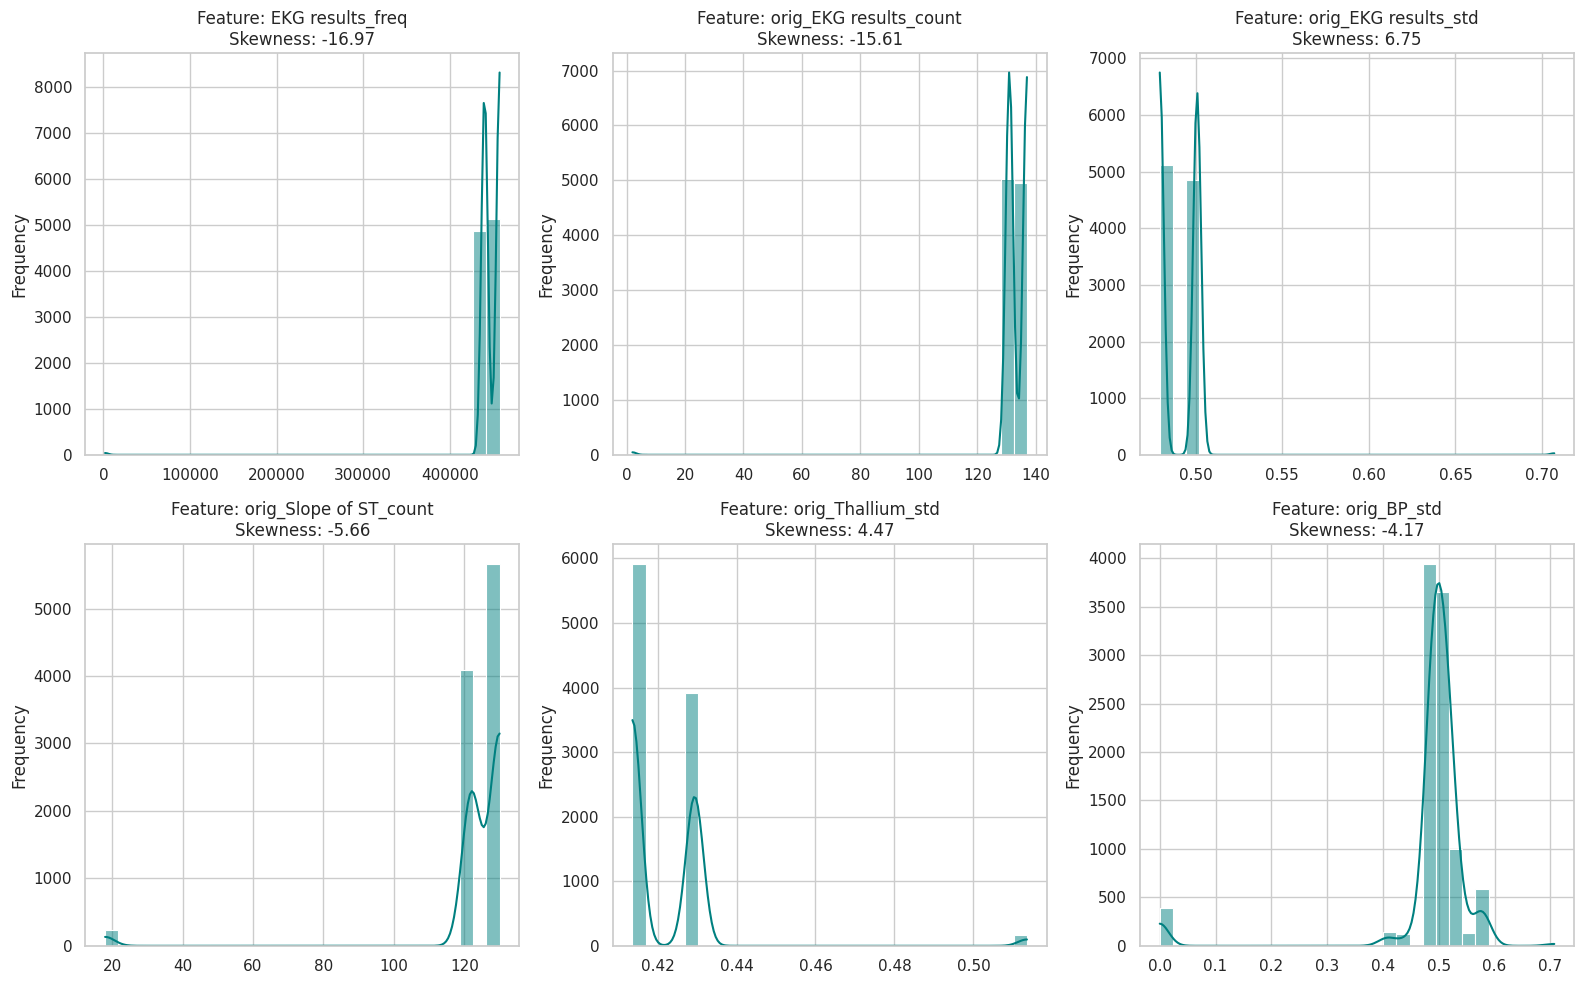

In [10]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

skew_series = X[numeric_cols].skew().abs().sort_values(ascending=False)
top_skewed_features = skew_series.head(6).index.tolist()

print("Top 6 Most Skewed Features (Absolute Values):")
print(X[top_skewed_features].skew())

plt.figure(figsize=(16, 10))
for i, col in enumerate(top_skewed_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(X[col].sample(min(10000, len(X))), kde=True, color='teal', bins=30)
    plt.title(f"Feature: {col}\nSkewness: {X[col].skew():.2f}")
    plt.xlabel("")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Cross-Validation & Training

In [11]:
%%time

# =========================
# Fixed params (Best from HPO)
# =========================
N_FOLDS = 5
RANDOM_STATE = 42
PRIMARY_CONFIG = "numeric_continuous"

params = {
    "device": DEVICE,              # "cuda" or "cpu"
    "random_state": RANDOM_STATE,
    "verbosity": 2,

    # training
    "n_epochs": 100,

    # best params (from your Optuna best)
    "batch_size": 2**12, # 128 or 512
    "n_ens": 8, # number of model: 8 or 12
    "act": "relu", # relu or mish
    "embedding_size": 4,
    "first_layer_lr_factor": 0.4909517357192525,
    "hidden_sizes": "rectangular",
    "hidden_width": 256,
    "lr": 0.009998859607801438, # 0.04 or 0.009
    "ls_eps": 0.010126807777508847,
    "ls_eps_sched": "coslog4",
    "max_one_hot_cat_size": 19,
    "n_hidden_layers": 6,
    "p_drop": 0.29904893015047485, #  0.07 or 0.02
    "p_drop_sched": "flat",
    "plr_hidden_1": 32,
    "plr_hidden_2": 8,
    "plr_lr_factor": 0.045999072301917396,
    "plr_sigma": 3.0846208639928108,
    "scale_lr_factor": 4.5960005947548925,
    "wd": 0.04967881042787047,

    # early stopping (best params)
    "use_early_stopping": True,
    "early_stopping_additive_patience": 20,
    "early_stopping_multiplicative_patience": 1.0,

    "val_metric_name": "1-auc_ovo",  # AUCベースでbest epoch選択
}

print("Using fixed params (submission-style):")
display(pd.Series(params))


Using fixed params (submission-style):


device                                           cuda
random_state                                       42
verbosity                                           2
n_epochs                                          100
batch_size                                       4096
n_ens                                               8
act                                              relu
embedding_size                                      4
first_layer_lr_factor                        0.490952
hidden_sizes                              rectangular
hidden_width                                      256
lr                                           0.009999
ls_eps                                       0.010127
ls_eps_sched                                  coslog4
max_one_hot_cat_size                               19
n_hidden_layers                                     6
p_drop                                       0.299049
p_drop_sched                                     flat
plr_hidden_1                

CPU times: user 2.75 ms, sys: 543 µs, total: 3.29 ms
Wall time: 2.96 ms


In [12]:
import time
from datetime import datetime
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score

feat = features[PRIMARY_CONFIG]
X = feat["X"].copy()
X_test = feat["X_test"].copy()
y = feat["y"].copy()

for col in feat["cat_cols"]:
    X[col] = X[col].astype(str).astype("category")
    X_test[col] = X_test[col].astype(str).astype("category")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_preds = np.zeros(len(X), dtype=np.float32)
test_preds = np.zeros(len(X_test), dtype=np.float32)
fold_scores = []

t_total_start = time.time()

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    t_fold_start = time.time()

    # ── フォールド開始ログ ──────────────────────────────
    print(f"\n{'='*55}")
    print(f"  Fold {fold}/{N_FOLDS}  |  started at {datetime.now().strftime('%H:%M:%S')}")
    print(f"{'='*55}")

    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]

    # SUB_FRAC = 0.3
    # sss = StratifiedShuffleSplit(
    #     n_splits=1,
    #     train_size=int(len(X_tr) * SUB_FRAC),
    #     random_state=RANDOM_STATE + fold
    # )
    # sub_idx, _ = next(sss.split(X_tr, y_tr))
    # X_tr = X_tr.iloc[sub_idx]
    # y_tr = y_tr.iloc[sub_idx]

    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    print(f"  [data]  train={len(X_tr):,}  val={len(X_val):,}  "
          f"pos_rate(tr)={y_tr.mean():.3f}  pos_rate(val)={y_val.mean():.3f}")

    # ── モデル学習 ──────────────────────────────────────
    print(f"  [fit]   starting RealMLP_TD training ...")
    t_fit = time.time()
    model = RealMLP_TD_Classifier(**params)
    model.fit(X_tr, y_tr.values, X_val, y_val.values)
    print(f"  [fit]   done in {time.time()-t_fit:.1f}s")

    # ── 予測 ────────────────────────────────────────────
    print(f"  [pred]  predicting val & test ...")
    val_probs  = model.predict_proba(X_val)[:, 1]
    test_probs = model.predict_proba(X_test)[:, 1]

    oof_preds[val_idx] = val_probs
    test_preds += test_probs / N_FOLDS

    # ── フォールドスコア ─────────────────────────────────
    score = roc_auc_score(y_val, val_probs)
    fold_scores.append(score)
    elapsed = time.time() - t_fold_start
    total_elapsed = time.time() - t_total_start

    eta = (total_elapsed / fold) * (N_FOLDS - fold)  # 残り時間推定

    print(f"\n  Fold {fold} AUC : {score:.5f}")
    print(f"  Scores so far : {[round(s,5) for s in fold_scores]}")
    print(f"  Running mean  : {np.mean(fold_scores):.5f}  ±  {np.std(fold_scores):.5f}")
    print(f"  Fold time     : {elapsed:.1f}s  |  Total: {total_elapsed:.1f}s  |  ETA: {eta:.1f}s")

    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        print("  [cuda]  cache cleared")

# ── 最終サマリー ──────────────────────────────────────
total_time = time.time() - t_total_start
mean_auc = float(np.mean(fold_scores))
std_auc  = float(np.std(fold_scores))
oof_auc  = float(roc_auc_score(y, oof_preds))

print(f"\n{'#'*55}")
print(f"  CV SUMMARY")
print(f"{'#'*55}")
print(f"  Fold scores : {[round(s,6) for s in fold_scores]}")
print(f"  Mean AUC    : {mean_auc:.6f}")
print(f"  Std AUC     : {std_auc:.6f}")
print(f"  OOF AUC     : {oof_auc:.6f}")
print(f"  Total time  : {total_time:.1f}s  ({total_time/60:.1f}min)")
print(f"{'#'*55}")


  Fold 1/5  |  started at 07:56:19
  [data]  train=504,000  val=126,000  pos_rate(tr)=0.448  pos_rate(val)=0.448
  [fit]   starting RealMLP_TD training ...
Columns classified as continuous: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'orig_Age_mean', 'orig_Age_median', 'orig_Age_std', 'orig_Age_skew', 'orig_Age_count', 'orig_Sex_mean', 'orig_Sex_median', 'orig_Sex_std', 'orig_Sex_skew', 'orig_Sex_count', 'orig_Chest pain type_mean', 'orig_Chest pain type_median', 'orig_Chest pain type_std', 'orig_Chest pain type_skew', 'orig_Chest pain type_count', 'orig_BP_mean', 'orig_BP_median', 'orig_BP_std', 'orig_BP_skew', 'orig_BP_count', 'orig_Cholesterol_mean', 'orig_Cholesterol_median', 'orig_Cholesterol_std', 'orig_Cholesterol_skew', 'orig_Cholesterol_count', 'orig_FBS over 120_mean', 'orig_FBS over 120_median', 'orig_FBS over 120_std', 'orig_FBS over 120_skew', 'orig_FBS over 120_count', 'orig_EKG results_mean', 'orig_EKG results_median', 'orig_EKG results_std', 'orig_EKG resul

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 1/100: val 1-auc_ovo = 0.053589
Epoch 2/100: val 1-auc_ovo = 0.046169
Epoch 3/100: val 1-auc_ovo = 0.045392
Epoch 4/100: val 1-auc_ovo = 0.045032
Epoch 5/100: val 1-auc_ovo = 0.044874
Epoch 6/100: val 1-auc_ovo = 0.044792
Epoch 7/100: val 1-auc_ovo = 0.044790
Epoch 8/100: val 1-auc_ovo = 0.044764
Epoch 9/100: val 1-auc_ovo = 0.044716
Epoch 10/100: val 1-auc_ovo = 0.044610
Epoch 11/100: val 1-auc_ovo = 0.044549
Epoch 12/100: val 1-auc_ovo = 0.044487
Epoch 13/100: val 1-auc_ovo = 0.044398
Epoch 14/100: val 1-auc_ovo = 0.044348
Epoch 15/100: val 1-auc_ovo = 0.044295
Epoch 16/100: val 1-auc_ovo = 0.044251
Epoch 17/100: val 1-auc_ovo = 0.044218
Epoch 18/100: val 1-auc_ovo = 0.044207
Epoch 19/100: val 1-auc_ovo = 0.044199
Epoch 20/100: val 1-auc_ovo = 0.044195
Epoch 21/100: val 1-auc_ovo = 0.044194
Epoch 22/100: val 1-auc_ovo = 0.044189
Epoch 23/100: val 1-auc_ovo = 0.044210
Epoch 24/100: val 1-auc_ovo = 0.044191
Epoch 25/100: val 1-auc_ovo = 0.044205
Epoch 26/100: val 1-auc_ovo = 0.04

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]



  Fold 1 AUC : 0.95594
  Scores so far : [np.float64(0.95594)]
  Running mean  : 0.95594  ±  0.00000
  Fold time     : 1189.0s  |  Total: 1189.0s  |  ETA: 4756.1s
  [cuda]  cache cleared

  Fold 2/5  |  started at 08:16:08
  [data]  train=504,000  val=126,000  pos_rate(tr)=0.448  pos_rate(val)=0.448
  [fit]   starting RealMLP_TD training ...
Columns classified as continuous: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'orig_Age_mean', 'orig_Age_median', 'orig_Age_std', 'orig_Age_skew', 'orig_Age_count', 'orig_Sex_mean', 'orig_Sex_median', 'orig_Sex_std', 'orig_Sex_skew', 'orig_Sex_count', 'orig_Chest pain type_mean', 'orig_Chest pain type_median', 'orig_Chest pain type_std', 'orig_Chest pain type_skew', 'orig_Chest pain type_count', 'orig_BP_mean', 'orig_BP_median', 'orig_BP_std', 'orig_BP_skew', 'orig_BP_count', 'orig_Cholesterol_mean', 'orig_Cholesterol_median', 'orig_Cholesterol_std', 'orig_Cholesterol_skew', 'orig_Cholesterol_count', 'orig_FBS over 120_mean', 'orig_FBS

...


  Fold 4 AUC : 0.95529
  Scores so far : [np.float64(0.95594), np.float64(0.95481), np.float64(0.9556), np.float64(0.95529)]
  Running mean  : 0.95541  ±  0.00041
  Fold time     : 1420.3s  |  Total: 5383.1s  |  ETA: 1345.8s
  [cuda]  cache cleared

  Fold 5/5  |  started at 09:26:02
  [data]  train=504,000  val=126,000  pos_rate(tr)=0.448  pos_rate(val)=0.448
  [fit]   starting RealMLP_TD training ...
Columns classified as continuous: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'orig_Age_mean', 'orig_Age_median', 'orig_Age_std', 'orig_Age_skew', 'orig_Age_count', 'orig_Sex_mean', 'orig_Sex_median', 'orig_Sex_std', 'orig_Sex_skew', 'orig_Sex_count', 'orig_Chest pain type_mean', 'orig_Chest pain type_median', 'orig_Chest pain type_std', 'orig_Chest pain type_skew', 'orig_Chest pain type_count', 'orig_BP_mean', 'orig_BP_median', 'orig_BP_std', 'orig_BP_skew', 'orig_BP_count', 'orig_Cholesterol_mean', 'orig_Cholesterol_median', 'orig_Cholesterol_std', 'orig_Cholesterol_skew',

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 1/100: val 1-auc_ovo = 0.053678
Epoch 2/100: val 1-auc_ovo = 0.046030
Epoch 3/100: val 1-auc_ovo = 0.045207
Epoch 4/100: val 1-auc_ovo = 0.044907
Epoch 5/100: val 1-auc_ovo = 0.044707
Epoch 6/100: val 1-auc_ovo = 0.044643
Epoch 7/100: val 1-auc_ovo = 0.044639
Epoch 8/100: val 1-auc_ovo = 0.044619
Epoch 9/100: val 1-auc_ovo = 0.044578
Epoch 10/100: val 1-auc_ovo = 0.044507
Epoch 11/100: val 1-auc_ovo = 0.044390
Epoch 12/100: val 1-auc_ovo = 0.044307
Epoch 13/100: val 1-auc_ovo = 0.044261
Epoch 14/100: val 1-auc_ovo = 0.044199
Epoch 15/100: val 1-auc_ovo = 0.044138
Epoch 16/100: val 1-auc_ovo = 0.044095
Epoch 17/100: val 1-auc_ovo = 0.044081
Epoch 18/100: val 1-auc_ovo = 0.044081
Epoch 19/100: val 1-auc_ovo = 0.044068
Epoch 20/100: val 1-auc_ovo = 0.044066
Epoch 21/100: val 1-auc_ovo = 0.044067
Epoch 22/100: val 1-auc_ovo = 0.044061
Epoch 23/100: val 1-auc_ovo = 0.044081
Epoch 24/100: val 1-auc_ovo = 0.044077
Epoch 25/100: val 1-auc_ovo = 0.044072
Epoch 26/100: val 1-auc_ovo = 0.04

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]



  Fold 5 AUC : 0.95606
  Scores so far : [np.float64(0.95594), np.float64(0.95481), np.float64(0.9556), np.float64(0.95529), np.float64(0.95606)]
  Running mean  : 0.95554  ±  0.00045
  Fold time     : 1288.4s  |  Total: 6671.4s  |  ETA: 0.0s
  [cuda]  cache cleared

#######################################################
  CV SUMMARY
#######################################################
  Fold scores : [np.float64(0.955935), np.float64(0.954812), np.float64(0.955597), np.float64(0.955286), np.float64(0.956055)]
  Mean AUC    : 0.955537
  Std AUC     : 0.000452
  OOF AUC     : 0.955500
  Total time  : 6671.4s  (111.2min)
#######################################################


### Model Evaluation

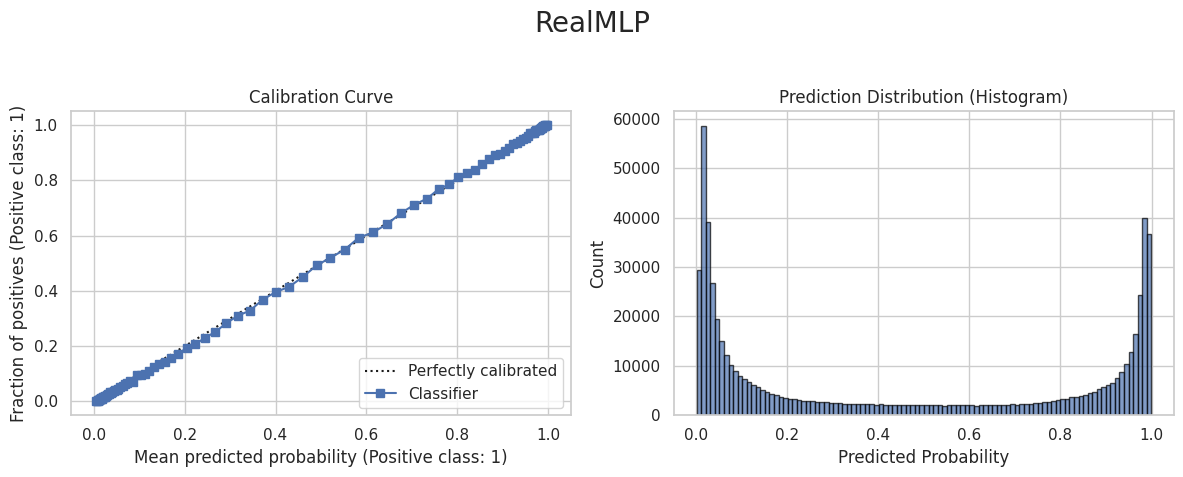

In [13]:
from sklearn.calibration import CalibrationDisplay

plt.figure(figsize=(12, 5))
plt.suptitle('RealMLP', fontsize=20)

ax1 = plt.subplot(1, 2, 1)
CalibrationDisplay.from_predictions(y, oof_preds, n_bins=100, strategy='quantile', ax=ax1)
ax1.set_title('Calibration Curve')

ax2 = plt.subplot(1, 2, 2)
ax2.hist(oof_preds, bins=100, edgecolor='black', alpha=0.7)
ax2.set_title('Prediction Distribution (Histogram)')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

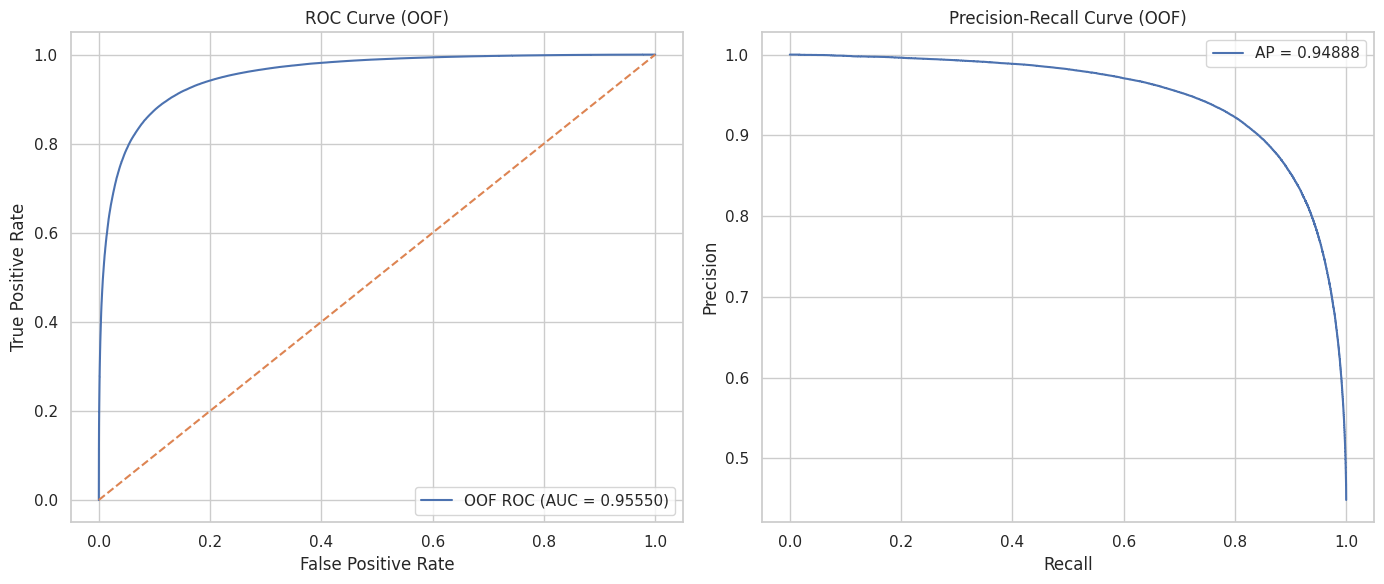

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# Create figure with 1 row, 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y, oof_preds)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, label=f'OOF ROC (AUC = {roc_auc:.5f})')
ax1.plot([0, 1], [0, 1], linestyle='--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve (OOF)')
ax1.legend()
ax1.grid(True)

# ---- Precision-Recall Curve ----
precision, recall, _ = precision_recall_curve(y, oof_preds)
ap = average_precision_score(y, oof_preds)

ax2.plot(recall, precision, label=f'AP = {ap:.5f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve (OOF)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


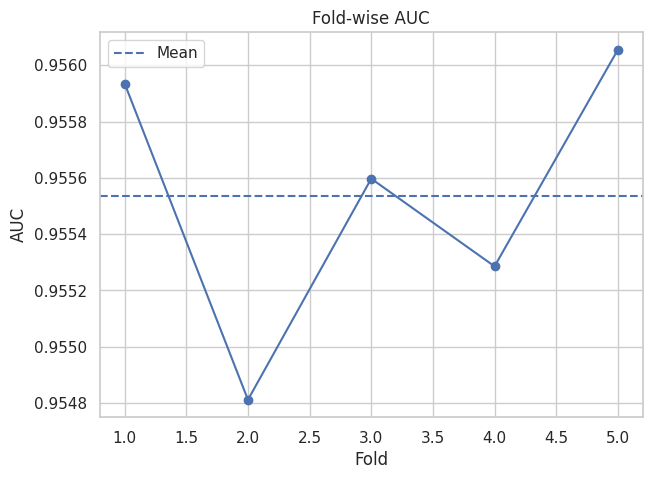

In [15]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, N_FOLDS+1), fold_scores, marker='o')
plt.axhline(np.mean(fold_scores), linestyle='--', label='Mean')

plt.xlabel('Fold')
plt.ylabel('AUC')
plt.title('Fold-wise AUC')
plt.legend()
plt.grid(True)
plt.show()


### Evaluation and Submission

In [16]:
total_oof_score = roc_auc_score(y, oof_preds)

print("\n" + "="*40)
print(f"Overall OOF ROC-AUC (avg OOF): {total_oof_score:.5f}")
print("="*40)



Overall OOF ROC-AUC (avg OOF): 0.95550


In [17]:
# Fold Scores Table
fold_df = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(len(fold_scores))],
    "ROC-AUC": fold_scores,
})
fold_df


,Fold,ROC-AUC
0,Fold 1,0.955935
1,Fold 2,0.954812
2,Fold 3,0.955597
3,Fold 4,0.955286
4,Fold 5,0.956055


In [18]:
submission = pd.DataFrame({'id': test['id'], 'Heart Disease': test_preds})
submission.to_csv('submission.csv', index=False)

print('Submission saved!')
print(f'Shape: {submission.shape}')

if len(submission) != 270000:
    raise ValueError(f"CRITICAL ERROR: Submission row count {len(submission)} != expected 270000")

submission.head()

Submission saved!
Shape: (270000, 2)


,id,Heart Disease
0,630000,0.954745
1,630001,0.012669
2,630002,0.984860
3,630003,0.009066
4,630004,0.192554
